# LangChain 基本範例

LangChain 可以把 Prompt、LLM 與輸出處理器組合成可重複使用的 Chain。

這份 notebook 將介紹：

1. 直接呼叫 LLM。
2. 使用 `PromptTemplate` 建立提示詞。
3. 使用 `StrOutputParser` 取得字串結果。
4. 使用 LCEL 的 `|` 組成 Chain。
5. 把兩條 Chain 組成簡單的多步驟流程。

## 1. Import libraries

In [2]:
import os

from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI

## 2. 建立 Chat Model

請先在系統環境變數中設定 `OPENAI_API_KEY`。也可以用 `OPENAI_MODEL` 更換模型；若未設定，預設使用 `gpt-4o-mini`。

In [3]:
llm_options = {
    "api_key": os.environ["OPENAI_API_KEY"],
    "model": os.getenv("OPENAI_MODEL", "gpt-4o-mini"),
    "temperature": 0.0,
}

if os.getenv("OPENAI_BASE_URL"):
    llm_options["base_url"] = os.environ["OPENAI_BASE_URL"]

llm = ChatOpenAI(**llm_options)

## 3. 直接呼叫 LLM

`invoke()` 是最基本的執行方法。Chat Model 回傳的是 `AIMessage`，回答文字位於 `.content`。

In [4]:
response = llm.invoke("請用一句話說明什麼是 LangChain。")

print(type(response))
print(response.content)

<class 'langchain_core.messages.ai.AIMessage'>
LangChain 是一個開源框架，旨在幫助開發者構建基於語言模型的應用，通過鏈接不同的組件來實現複雜的自然語言處理任務。


## 4. 建立 PromptTemplate

Prompt Template 將固定指示與變動資料分開。`{topic}` 與 `{audience}` 是執行時才填入的變數。

In [5]:
prompt = PromptTemplate.from_template(
    "你是一位耐心的老師。請用三個條列重點，向{audience}解釋{topic}。"
)

In [6]:
formatted_prompt = prompt.invoke(
    {"topic": "大型語言模型", "audience": "初學者"}
)

print(formatted_prompt.text)

你是一位耐心的老師。請用三個條列重點，向初學者解釋大型語言模型。


## 5. 建立 Output Parser

LLM 原本回傳 `AIMessage`。`StrOutputParser` 會取出其中的文字，讓 Chain 最後直接得到 Python 字串。

In [7]:
parser = StrOutputParser()

## 6. 不使用 LCEL 的寫法

以下程式明確呈現資料依序經過 Prompt、LLM、Parser。

In [8]:
prompt_value = prompt.invoke(
    {"topic": "LangChain", "audience": "Python 初學者"}
)
ai_message = llm.invoke(prompt_value)
answer = parser.invoke(ai_message)

print(answer)

當然可以！以下是三個重點，幫助Python初學者理解LangChain：

1. **什麼是LangChain**：
   LangChain是一個開源框架，旨在幫助開發者構建基於語言模型的應用程式。它提供了一系列工具和組件，使得與大型語言模型（如GPT-3、GPT-4等）的互動變得更加簡單和高效。

2. **核心組件**：
   LangChain的核心組件包括「鏈（Chains）」、「記憶（Memory）」和「代理（Agents）」。這些組件可以幫助開發者設計複雜的工作流程，例如將多個語言模型的輸出串聯起來，或是根據用戶的上下文記住信息，從而提供更個性化的回應。

3. **應用場景**：
   LangChain可以用於多種應用場景，如聊天機器人、文本生成、問答系統等。透過LangChain，開發者可以更輕鬆地構建出能夠理解和生成自然語言的智能應用，並且能夠快速迭代和測試不同的模型和策略。

希望這些重點能幫助你更好地理解LangChain！如果有任何問題，隨時可以問我。


## 7. 使用 LCEL 組成 Chain

LCEL（LangChain Expression Language）使用 `|` 表示資料流向：

```text
輸入字典 → PromptTemplate → ChatOpenAI → StrOutputParser → 字串
```

In [9]:
chain = prompt | llm | parser

In [10]:
result = chain.invoke(
    {"topic": "LangChain", "audience": "Python 初學者"}
)

print(result)
print(type(result))

當然可以！以下是三個重點，幫助Python初學者理解LangChain：

1. **什麼是LangChain**：
   LangChain是一個開源框架，旨在幫助開發者構建基於語言模型的應用程式。它提供了一系列工具和組件，使得與大型語言模型（如GPT-3、GPT-4等）的互動變得更加簡單和高效。

2. **核心組件**：
   LangChain的核心組件包括「鏈（Chains）」、「記憶（Memory）」和「代理（Agents）」。這些組件可以幫助開發者設計複雜的對話流程、保持上下文記憶，並根據用戶的輸入自動選擇合適的行動。

3. **應用場景**：
   LangChain可以用於多種應用場景，例如聊天機器人、智能助手、內容生成和數據分析等。透過LangChain，開發者可以更輕鬆地創建具有自然語言理解能力的應用，提升用戶體驗。

希望這些重點能幫助你更好地理解LangChain！如果有任何問題，隨時可以問我。
<class 'langchain_core.messages.base.TextAccessor'>


`|` 並不是單純的字串串接。Prompt、LLM 與 Parser 都實作了 LangChain 的 Runnable 介面，因此可以組合並統一使用 `invoke()`、`batch()` 和 `stream()`。

## 8. Batch 與 Stream

同一條 Chain 可以一次處理多個輸入，也可以逐段輸出結果。

In [11]:
batch_results = chain.batch(
    [
        {"topic": "API", "audience": "初學者"},
        {"topic": "Prompt", "audience": "初學者"},
    ]
)

for item in batch_results:
    print(item)
    print("---")

當然可以！以下是三個重點，幫助初學者理解API（應用程式介面）：

1. **定義與功能**：
   - API（Application Programming Interface）是一組定義了不同軟體應用程式之間如何互相溝通的規則和協議。它允許不同的系統或應用程式之間交換數據和功能，像是一個橋樑，讓它們能夠協同工作。

2. **請求與回應**：
   - 使用API時，通常會發送請求（request）到伺服器，伺服器根據請求的內容進行處理，然後返回一個回應（response）。這個過程可以是獲取數據（例如，從資料庫中查詢資訊）或執行某個操作（例如，更新用戶資料）。

3. **實際應用**：
   - API在日常生活中有很多應用，例如社交媒體平台的API允許開發者創建應用程式來發佈帖子或獲取用戶資料；天氣API可以讓應用程式獲取即時的天氣資訊。這些API使得開發者能夠利用現有的服務和數據，快速構建新的應用程式。

希望這些重點能幫助你更好地理解API的概念！如果有任何問題，隨時可以問我。
---
當然可以！以下是三個重點，幫助初學者理解「Prompt」的概念：

1. **定義**：Prompt 是一個指令或問題，通常用來引導人工智慧（如聊天機器人或生成模型）生成回應或內容。它可以是簡單的問題、具體的指示或開放式的主題。

2. **用途**：在使用人工智慧時，良好的 Prompt 可以幫助用戶獲得更準確和相關的回應。透過清晰且具體的提示，用戶可以引導 AI 生成所需的資訊、故事、建議等。

3. **示例**：例如，如果你想讓 AI 幫你寫一篇關於環保的文章，好的 Prompt 可能是「請寫一篇關於如何減少塑料使用的環保文章」。這樣的提示能夠讓 AI 更好地理解你的需求並提供相應的內容。

希望這些重點能幫助你更好地理解 Prompt 的概念！
---


In [12]:
for chunk in chain.stream(
    {"topic": "LCEL", "audience": "初學者"}
):
    print(chunk, end="", flush=True)

當然可以！以下是三個重點，幫助初學者理解LCEL（Language, Culture, Education, and Learning）：

1. **語言（Language）**：
   - LCEL強調語言在學習過程中的重要性。語言不僅是交流的工具，也是文化和知識的載體。學習一種語言可以幫助我們更好地理解和融入不同的文化。

2. **文化（Culture）**：
   - 文化是影響學習和交流的背景因素。LCEL鼓勵學習者探索不同文化的價值觀、習俗和傳統，這樣可以增進對他人觀點的理解，並促進跨文化交流。

3. **教育與學習（Education and Learning）**：
   - LCEL強調教育的多樣性和靈活性，提倡以學生為中心的學習方法。這意味著教育應該根據學生的需求和背景進行調整，以促進更有效的學習體驗。

這三個重點共同構成了LCEL的核心理念，幫助學習者在語言學習的同時，理解文化背景並提升教育效果。

## 9. 簡單的多步驟 Chain

接下來把第一條 Chain 產生的教學內容交給第二個 Prompt，請 LLM 根據內容產生測驗題：

```text
主題 → 產生教學內容 → 產生測驗題 → 字串結果
```

In [13]:
lesson_prompt = PromptTemplate.from_template(
    "請用簡單的方式介紹 {topic}，內容限制在 150 字以內。"
)
lesson_chain = lesson_prompt | llm | parser

quiz_prompt = PromptTemplate.from_template(
    "根據以下教學內容，產生一題四選一測驗，並在最後提供答案：\n\n{lesson}"
)

multi_step_chain = (
    {"lesson": lesson_chain}
    | quiz_prompt
    | llm
    | parser
)

In [14]:
quiz = multi_step_chain.invoke({"topic": "LangChain"})
print(quiz)

**測驗題目：**

LangChain 是一個旨在幫助開發者構建什麼類型的應用程式的開源框架？

A) 圖形設計應用程式  
B) 基於語言模型的應用程式  
C) 數據分析工具  
D) 網頁開發框架  

**答案：** B) 基於語言模型的應用程式


## 10. 查看 Chain 結構

In [ ]:
multi_step_chain.get_graph().print_ascii()

Note: you may need to restart the kernel to use updated packages.
+-----------------------+  
| Parallel<lesson>Input |  
+-----------------------+  
            *              
            *              
            *              
    +----------------+     
    | PromptTemplate |     
    +----------------+     
            *              
            *              
            *              
      +------------+       
      | ChatOpenAI |       
      +------------+       
            *              
            *              
            *              
   +-----------------+     
   | StrOutputParser |     
   +-----------------+     
            *              
            *              
            *              
    +----------------+     
    | PromptTemplate |     
    +----------------+     
            *              
            *              
            *              
      +------------+       
      | ChatOpenAI |       
      +------------+       
          

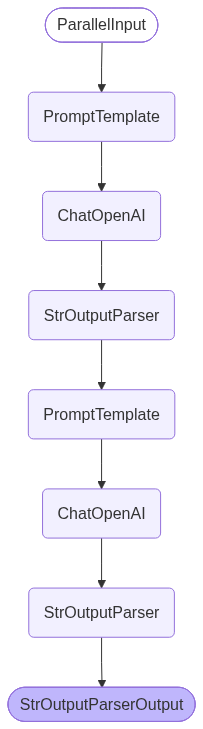

In [19]:
from IPython.display import Image, display

display(
    Image(
        multi_step_chain.get_graph().draw_mermaid_png()
    )
)

## 重點整理

| 元件 | 用途 |
|---|---|
| `PromptTemplate` | 將輸入資料填入提示詞 |
| `ChatOpenAI` | 將提示詞送給語言模型 |
| `StrOutputParser` | 將 `AIMessage` 轉成字串 |
| `|` | 使用 LCEL 串接 Runnable |
| `invoke()` | 執行一次 |
| `batch()` | 一次處理多筆輸入 |
| `stream()` | 逐段取得輸出 |

最基本的 LangChain 寫法就是：

```python
chain = prompt | llm | parser
result = chain.invoke(input_data)
```